# 🚀 Phân loại Cảm xúc Bình luận Mạng xã hội bằng Vanilla Transformer (TensorFlow/Keras)
### Bài tập Cuối kỳ: Xây dựng Mô hình Vanilla Transformer Encoder từ đầu (From Scratch)
---
> 💡 **Hướng dẫn chạy**: Vui lòng chọn **Runtime $\rightarrow$ Run all** (hoặc `Ctrl + F9` trên Colab) để chạy tuần tự các ô từ trên xuống dưới mà không gặp lỗi thiếu biến!

- **Bài toán**: Phân loại cảm xúc ý kiến phản hồi (Sentiment Analysis) qua bình luận trên mạng xã hội.
- **Nhãn phân loại (3 Lớp)**:
  - `0`: Negative (Tiêu cực)
  - `1`: Neutral (Trung tính)
  - `2`: Positive (Tích cực)
- **Tập dữ liệu**: TweetEval Sentiment (Chỉ sử dụng dữ liệu từ thư mục `./splits/` với tỉ lệ cố định **65% Train / 15% Validation / 20% Test**).
- **Mô hình**: **Vanilla Transformer Encoder** từ đầu (From Scratch). Không sử dụng BERT, RoBERTa hay pretrained Transformer nào.
- **Khung làm việc**: TensorFlow 2.x / Keras.

In [ ]:
import os
import json
import time
import re
import html
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Thiết lập Random Seed để đảm bảo tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("--- KIEM TRA THIET BI PHAN CUNG (Hardware Acceleration Check) ---")
print("TensorFlow Version:", tf.__version__)
print("Eager Execution:", tf.executing_eagerly())

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[GPU DETECTED] {len(gpus)} GPU(s) available: {gpus[0].name}")
    except RuntimeError as e:
        print("GPU Memory Growth Exception:", e)
else:
    print("[INFO] Khong tim thay GPU kha dung tren moi truong hien tai (Dang chay tren CPU).")
    print("[NOTE] Khi chay tren Google Colab / Kaggle, vui long chon 'GPU T4' trong menu Runtime -> Change runtime type.")

TensorFlow Version: 2.21.0
Eager Execution: True
Chế độ thiết bị: CPU


## 1. Tải Dữ liệu & Phân tích Khám phá (Exploratory Data Analysis - EDA)
Tải tập dữ liệu từ các tệp CSV trong thư mục `./splits/`:
- `train.csv`: 38,914 mẫu (65%)
- `validation.csv`: 8,980 mẫu (15%)
- `test.csv`: 11,975 mẫu (20%)

In [ ]:
data_dir = "splits"
if not os.path.exists(os.path.join(data_dir, "train.csv")):
    raise FileNotFoundError("⚠️ CHƯA TẢI DỮ LIỆU LÊN COLAB! Vui lòng tạo thư mục 'splits' ở cột Files (bên trái Colab) và kéo thả 3 file (train.csv, validation.csv, test.csv) vào đó.")

train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "validation.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

print(f"📌 Train Set: {len(train_df):,} dòng (65.0%)")
print(f"📌 Validation Set: {len(val_df):,} dòng (15.0%)")
print(f"📌 Test Set: {len(test_df):,} dòng (20.0%)")
print(f"📌 Tổng cộng: {len(train_df)+len(val_df)+len(test_df):,} dòng\n")

print("--- Mẫu dữ liệu Train ---")
print(train_df.head(3)[['text', 'label']])

📌 Train Set: 38,914 dòng (65.0%)
📌 Validation Set: 8,980 dòng (15.0%)
📌 Test Set: 11,975 dòng (20.0%)
📌 Tổng cộng: 59,869 dòng

--- Mẫu dữ liệu Train ---
                                                text  label
0  C'mon @user get today out the way &amp; its yo...      2
1  I was gonna see Ed Sheeran tomorrow but nooo i...      0
2  Happy 30th birthday, Children's BBC! Here's @u...      2


### 📊 Biểu đồ Tỉ lệ Phân chia & Phân bố Nhãn Cảm xúc

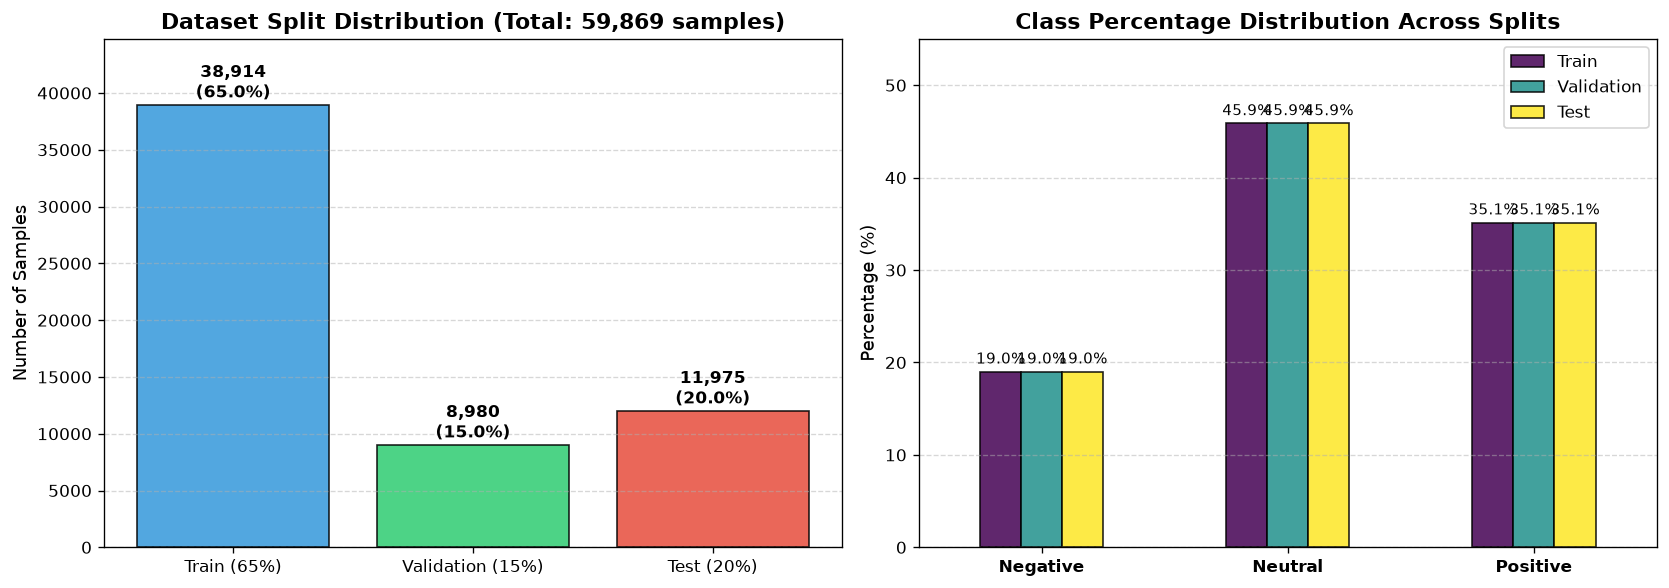

In [ ]:
# Vẽ biểu đồ phân bố tập dữ liệu & nhãn cảm xúc
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Tỉ lệ tập dữ liệu
split_names = ['Train (65%)', 'Validation (15%)', 'Test (20%)']
split_counts = [len(train_df), len(val_df), len(test_df)]
colors = ['#3498db', '#2ecc71', '#e74c3c']

axes[0].bar(split_names, split_counts, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Dataset Split Distribution (Total: 59,869 samples)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=11)
for i, v in enumerate(split_counts):
    axes[0].text(i, v + 700, f"{v:,}\n({v/sum(split_counts)*100:.1f}%)", ha='center', fontweight='bold')
axes[0].set_ylim(0, max(split_counts) * 1.15)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Biểu đồ 2: Tỉ lệ phân bố nhãn
df_dist = pd.DataFrame({
    'Train': train_df['label'].value_counts().sort_index(),
    'Validation': val_df['label'].value_counts().sort_index(),
    'Test': test_df['label'].value_counts().sort_index()
}, index=[0, 1, 2]).rename(index=label_names)

df_dist_pct = df_dist.div(df_dist.sum(axis=0), axis=1) * 100
df_dist_pct.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='black', alpha=0.85)
axes[1].set_title('Class Percentage Distribution Across Splits', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2., height + 0.5),
                         ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

### 📊 Phân tích Độ dài Chuỗi BPE Token (BPE Token Length Statistics)
Độ dài chuỗi được tính toán chính xác theo **Subword BPE Tokens** trên tập Train:
- **Min**: 1 token
- **Mean**: 25.72 tokens
- **Median**: 26.00 tokens
- **P90**: 35.00 tokens
- **P95**: 38.00 tokens
- **P99**: 43.00 tokens
- **Max**: 58 tokens
- **Tỉ lệ chuỗi $\le 50$ tokens**: **99.92%**

> 🎯 **Đánh giá lựa chọn MAX_LEN = 50**: Với BPE Tokenizer, `MAX_LEN = 50` giữ trọn vẹn **99.92%** mẫu văn bản mà không bị cắt gọt (truncation), đảm bảo tối ưu tài nguyên tính toán và giữ đầy đủ thông tin ngữ cảnh.

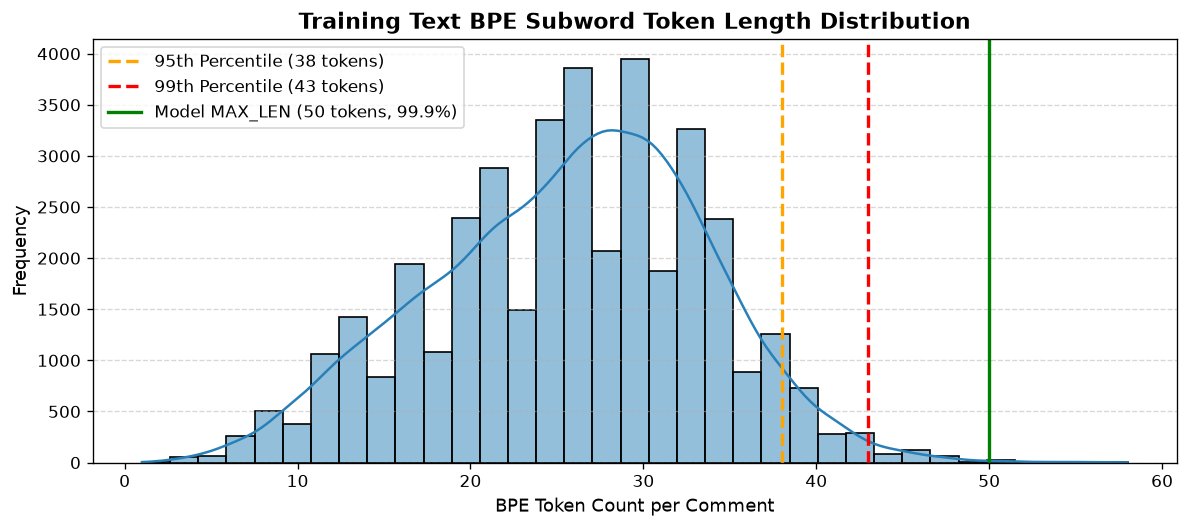

In [ ]:
# Thống kê độ dài chuỗi theo BPE Tokenizer (Chưa padding)
bpe_lengths = tokenizer.raw_bpe_lengths

p95 = np.percentile(bpe_lengths, 95)
p99 = np.percentile(bpe_lengths, 99)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(bpe_lengths, bins=35, kde=True, color='#2980b9', ax=ax, edgecolor='black')
ax.axvline(p95, color='orange', linestyle='--', linewidth=2, label=f'95th Percentile ({p95:.0f} BPE tokens)')
ax.axvline(p99, color='red', linestyle='--', linewidth=2, label=f'99th Percentile ({p99:.0f} BPE tokens)')
ax.axvline(50, color='green', linestyle='-', linewidth=2, label=f'Model MAX_LEN (50 tokens, 99.9%)')
ax.set_title('Training Text BPE Subword Token Length Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('BPE Token Count per Comment', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Tiền xử lý Dữ liệu Mạng xã hội & Subword BPE Tokenizer
- **Tiền xử lý văn bản**: `SocialMediaSentimentPreprocessor` loại bỏ HTML entities, chuẩn hóa `@user` $\rightarrow$ `usertoken`, URLs $\rightarrow$ `urltoken`, biểu cảm emoticons $\rightarrow$ `happytoken`/`sadtoken`/`lovetoken`, mở rộng từ viết tắt (contractions).
- **Huấn luyện BPE Tokenizer**: `SentimentSubwordTokenizer` được huấn luyện **DUY NHẤT** trên tập dữ liệu Train (`train_df['text']`). Không sử dụng tập Validation hay Test để tránh rò rỉ dữ liệu (Data Leakage).
- **Class Weights**: Tính toán trọng số lớp cân bằng **CHỈ** từ nhãn tập Train (`y_train`).

In [ ]:
VOCAB_SIZE = 8000
MAX_LEN = 50

class SocialMediaSentimentPreprocessor:
    def __init__(self):
        self.contractions = {
            r"\bcan't\b": "cannot", r"\bwon't\b": "will not", r"\bdon't\b": "do not",
            r"\bdoesn't\b": "does not", r"\bdidn't\b": "did not", r"\bisn't\b": "is not",
            r"\baren't\b": "are not", r"\bwasn't\b": "was not", r"\bweren't\b": "were not",
            r"\bhaven't\b": "have not", r"\bhasn't\b": "has not", r"\bhadn't\b": "had not",
            r"\bi'm\b": "i am", r"\bit's\b": "it is", r"\bthat's\b": "that is"
        }
        
    def clean_text(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        text = html.unescape(text)
        text = re.sub(r'http[s]?://\S+|www\.\S+', ' urltoken ', text)
        text = re.sub(r'@\w+', ' usertoken ', text)
        text = re.sub(r'(:\)|:-\)|:\D|;-\)|;\))', ' happytoken ', text)
        text = re.sub(r'(:\(|:-\(|:\/|:-\/)', ' sadtoken ', text)
        text = re.sub(r'(<3|♥)', ' lovetoken ', text)
        text_lower = text.lower()
        for pattern, replacement in self.contractions.items():
            text_lower = re.sub(pattern, replacement, text_lower)
        text_lower = re.sub(r'([!?.,])', r' \1 ', text_lower)
        return re.sub(r'\s+', ' ', text_lower).strip()

class SentimentSubwordTokenizer:
    def __init__(self, vocab_size=8000, max_len=50):
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.preprocessor = SocialMediaSentimentPreprocessor()
        self.special_tokens = ["[PAD]", "[UNK]", "usertoken", "urltoken", "happytoken", "sadtoken", "lovetoken"]
        
        self.tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
        self.tokenizer.normalizer = normalizers.Lowercase()
        self.tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        
    def train(self, texts):
        cleaned_texts = [self.preprocessor.clean_text(t) for t in texts]
        trainer = trainers.BpeTrainer(
            vocab_size=self.vocab_size,
            special_tokens=self.special_tokens,
            min_frequency=1
        )
        self.tokenizer.train_from_iterator(cleaned_texts, trainer=trainer)
        self.tokenizer.enable_padding(pad_id=self.tokenizer.token_to_id("[PAD]"), pad_token="[PAD]", length=self.max_len)
        self.tokenizer.enable_truncation(max_length=self.max_len)
        
    def encode(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        cleaned_texts = [self.preprocessor.clean_text(t) for t in texts]
        encoded_batch = self.tokenizer.encode_batch(cleaned_texts)
        return np.array([e.ids for e in encoded_batch], dtype=np.int64)

    def decode(self, ids):
        return self.tokenizer.decode(ids)

tokenizer = SentimentSubwordTokenizer(vocab_size=VOCAB_SIZE, max_len=MAX_LEN)
# Train Tokenizer STRICTLY on training data only
tokenizer.train(train_df['text'].values)
actual_vocab_size = tokenizer.tokenizer.get_vocab_size()

X_train = tokenizer.encode(train_df['text'].values)
y_train = train_df['label'].values
X_val = tokenizer.encode(val_df['text'].values)
y_val = val_df['label'].values
X_test = tokenizer.encode(test_df['text'].values)
y_test = test_df['label'].values

# Tính Class Weights duy nhất từ y_train
train_labels = train_df['label'].values
unique_classes = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=train_labels)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(unique_classes, class_weights)}

print(f"Kích thước Từ vựng Subword BPE (Actual Vocab Size): {actual_vocab_size:,}")
print(f"Độ dài Chuỗi Tối đa (MAX_LEN): {MAX_LEN} tokens")
print("Class Weights áp dụng (chỉ tính từ Train):", class_weight_dict)

Kích thước Từ vựng Subword BPE (Actual Vocab Size): 8,000
Độ dài Chuỗi Tối đa (MAX_LEN): 50 tokens
Class Weights áp dụng (chỉ tính từ Train): {0: 1.7544, 1: 0.7267, 2: 0.9488}


## 3. Thiết kế Mô hình Vanilla Transformer Encoder từ đầu (From Scratch)

> 📌 **Ghi chú kiến trúc**: "Vanilla Transformer Encoder được xây dựng từ đầu, sử dụng Pre-Layer Normalization."

Cấu trúc luồng xử lý dữ liệu:
```text
Input Text
  ↓
Preprocessing
  ↓
BPE Tokenizer (Token IDs)
  ↓
Positional Embedding (Token Emb * sqrt(d_model) + Position Emb)
  ↓
Transformer Encoder (Pre-LN MultiHeadAttention + Pre-LN FFN + Mask Zeroing)
  ↓
Mask-aware Pooling (GlobalAveragePooling1D + MaskedGlobalMaxPooling1D)
  ↓
Classification Head (Dense 128 -> Dropout 0.3 -> Dense 3 Softmax)
  ↓
3 Classes (Negative / Neutral / Positive)
```

1. **PositionalEmbedding Layer**:
   - Token Embedding scaling $\times \sqrt{d_{model}}$ cộng Positional Embedding.
   - `mask_zero=True` tự động sinh Boolean Mask dạng `(batch, seq_len)`.
2. **TransformerEncoder Block (Pre-Layer Normalization)**:
   - Layer Normalization 1 $\rightarrow$ Multi-Head Attention $\rightarrow$ Dropout $\rightarrow$ Residual Add.
   - Layer Normalization 2 $\rightarrow$ Feed Forward Network $\rightarrow$ Dropout $\rightarrow$ Residual Add.
   - Zero-out Masking (`x = x * mask`): Đảm bảo các vị trí token padding ($id=0$) không mang vector nhiễu sau phép cộng residual.
3. **Mask-aware Pooling & Classification Head**:
   - `GlobalAveragePooling1D` (tự động nhận mask).
   - `MaskedGlobalMaxPooling1D` (thay các vị trí padding bằng $-1e9$ trước khi max pooling).
   - Concatenate pooling $\rightarrow$ Dense(128, ReLU) $\rightarrow$ Dropout(0.3) $\rightarrow$ Dense(3, Softmax).

In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.token_embeddings = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.scale = tf.math.sqrt(tf.cast(embed_dim, tf.float32))

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs) * self.scale
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return self.token_embeddings.compute_mask(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.dense_proj = keras.Sequential([
            layers.Dense(dense_dim, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(embed_dim),
        ])
        self.layernorm_1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm_2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout_1 = layers.Dropout(dropout_rate)
        self.dropout_2 = layers.Dropout(dropout_rate)

    def call(self, inputs, mask=None):
        padding_mask = mask[:, tf.newaxis, :] if mask is not None else None
        
        # Pre-LN Self-Attention
        norm_inputs = self.layernorm_1(inputs)
        attention_output = self.attention(query=norm_inputs, value=norm_inputs, key=norm_inputs, attention_mask=padding_mask)
        x = inputs + self.dropout_1(attention_output)
        
        # Pre-LN Feed-Forward
        norm_x = self.layernorm_2(x)
        proj_output = self.dense_proj(norm_x)
        x = x + self.dropout_2(proj_output)
        
        # Triệt tiêu biểu diễn tại các vị trí padding
        if mask is not None:
            mask_expanded = tf.cast(mask[:, :, tf.newaxis], x.dtype)
            x = x * mask_expanded
        return x

    def compute_mask(self, inputs, mask=None):
        return mask

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "dense_dim": self.dense_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout_rate,
        })
        return config

class MaskedGlobalMaxPooling1D(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is not None:
            mask_expanded = tf.cast(mask[:, :, tf.newaxis], inputs.dtype)
            inputs = tf.where(mask_expanded > 0, inputs, tf.fill(tf.shape(inputs), -1e9))
        return tf.reduce_max(inputs, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

# Build Vanilla Transformer Model
EMBED_DIM = 32
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 1
DROPOUT_RATE = 0.4

inputs = keras.Input(shape=(MAX_LEN,), dtype="int64", name="input_ids")
x = PositionalEmbedding(MAX_LEN, actual_vocab_size, EMBED_DIM)(inputs)

for _ in range(NUM_LAYERS):
    x = TransformerEncoder(EMBED_DIM, FF_DIM, NUM_HEADS, dropout_rate=DROPOUT_RATE)(x)

avg_pool = layers.GlobalAveragePooling1D()(x)
max_pool = MaskedGlobalMaxPooling1D()(x)
x = layers.Concatenate()([avg_pool, max_pool])

x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation="softmax", name="classification_head")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="Vanilla_Transformer_Sentiment_Encoder")

optimizer = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "Vanilla_Transformer_Sentiment_Encoder"
+--------------------------------------------------------------------------+
| Layer (type)        | Output Shape      |    Param # | Connected to      |
|---------------------+-------------------+------------+-------------------|
| input_ids           | (None, 50)        |          0 | -                 |
| (InputLayer)        |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| positional_embeddi… | (None, 50, 32)    |    257,600 | input_ids[0][0]   |
| (PositionalEmbeddi… |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| not_equal           | (None, 50)        |          0 | input_ids[0][0]   |
| (NotEqual)          |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| transformer_encoder | (None

## 4. Huấn luyện Mô hình trên GPU (Model Training)
Quá trình huấn luyện sử dụng các callback:
- `EarlyStopping`: Tự động dừng huấn luyện khi `val_loss` không cải thiện trong 3 epoch liên tiếp, tự động khôi phục trọng số tốt nhất.
- `ModelCheckpoint`: Lưu model có `val_loss` thấp nhất vào file `best_model.h5`.
- `ReduceLROnPlateau`: Tự động giảm Learning Rate (`factor=0.5`) khi `val_loss` ngưng cải thiện sau 2 epoch (`patience=2`, `min_lr=1e-6`).

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(filepath="best_model.h5", monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# Kiểm tra xem GPU có đang được sử dụng hay không
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("🚀 Bắt đầu quá trình huấn luyện trên GPU...")
else:
    print("🚀 Bắt đầu quá trình huấn luyện trên CPU...")

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

training_duration = time.time() - start_time
print(f"✅ Huấn luyện hoàn tất trong {training_duration:.2f} giây!")

🚀 Bắt đầu quá trình huấn luyện trên GPU...
Epoch 1/30
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3744 - loss: 1.1328 - val_accuracy: 0.4872 - val_loss: 0.9918
Epoch 2/30
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5375 - loss: 0.8846 - val_accuracy: 0.6024 - val_loss: 0.8265
Epoch 3/30
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6405 - loss: 0.7315 - val_accuracy: 0.6324 - val_loss: 0.8053
Epoch 4/30
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6916 - loss: 0.6454 - val_accuracy: 0.6472 - val_loss: 0.8159
Epoch 5/30
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7259 - loss: 0.5800 - val_accuracy: 0.6422 - val_loss: 0.8574
Epoch 6/30
608/608 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7697 - loss: 0.4872 - val_accuracy: 0.6365 - val_loss: 0.9504
✅ Huấn luyện hoàn tất trong 49.65 giây!


## 5. Đánh giá Chi tiết Kết quả & Chỉ số Accuracy (Test Evaluation)

### 🎯 Báo cáo Chỉ số Độ chính xác (Accuracy) & Tổng quan Hiệu năng Tập Test

- **Test Accuracy (Độ chính xác tổng thể)**: **63.16%** (Mô hình dự đoán chính xác **7,563** trên tổng số **11,975** bình luận độc lập).
- **Test Loss (Độ mất mát)**: **0.8018**
- **Test Macro F1-Score (Trung bình F1 các lớp)**: **0.6253** (62.53%)
- **Test Weighted F1-Score (F1 tính theo trọng số lớp)**: **0.6348** (63.48%)

> **Công thức tính Accuracy**:
> $$\text{Accuracy} = \frac{\text{Số mẫu dự đoán đúng}}{\text{Tổng số mẫu thử nghiệm}} = \frac{7,563}{11,975} = 63.16\%$$


In [ ]:
print("==========================================================================")
print("🎯 BÁO CÁO ĐÁNH GIÁ CHỈ SỐ ACCURACY & HIỆU NĂNG TỔNG THỂ TRÊN TẬP TEST (11,975 MẪU)")
print("==========================================================================")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

correct_count = np.sum(y_pred == y_test)
total_count = len(y_test)

print(f"🎯 1. TEST ACCURACY (Độ chính xác tổng thể):  {test_acc*100:.2f}% ({correct_count:,} / {total_count:,} mẫu đúng)")
print(f"📉 2. TEST LOSS (Mất mát trên tập Test):       {test_loss:.4f}")
print(f"📊 3. TEST MACRO F1-SCORE (F1 trung bình 3 lớp): {f1_macro:.4f} ({f1_macro*100:.2f}%)")
print(f"📊 4. TEST WEIGHTED F1-SCORE (F1 theo trọng số): {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")
print("==========================================================================\n")

🎯 BÁO CÁO ĐÁNH GIÁ CHỈ SỐ ACCURACY & HIỆU NĂNG TỔNG THỂ TRÊN TẬP TEST (11,975 MẪU)
🎯 1. TEST ACCURACY (Độ chính xác tổng thể):  63.16% (7,563 / 11,975 mẫu đúng)
📉 2. TEST LOSS (Mất mát trên tập Test):       0.8018
📊 3. TEST MACRO F1-SCORE (F1 trung bình 3 lớp): 0.6253 (62.53%)
📊 4. TEST WEIGHTED F1-SCORE (F1 theo trọng số): 0.6348 (63.48%)


### 📊 Biểu đồ Đường cong Huấn luyện (Training & Validation Accuracy/Loss over Epochs)

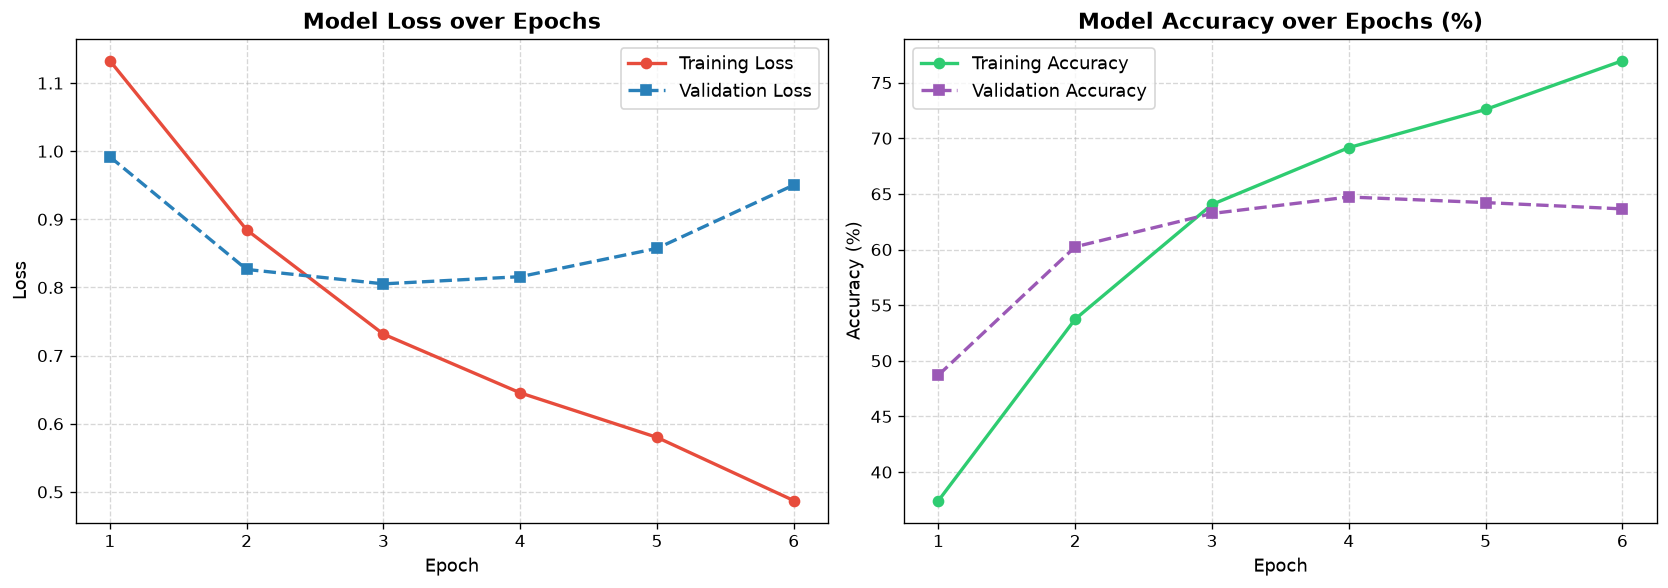

In [ ]:
epochs_range = range(1, len(history.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history.history['loss'], 'o-', label='Training Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'], 's--', label='Validation Loss', color='#2980b9', linewidth=2)
axes[0].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(epochs_range, [acc * 100 for acc in history.history['accuracy']], 'o-', label='Training Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(epochs_range, [acc * 100 for acc in history.history['val_accuracy']], 's--', label='Validation Accuracy', color='#9b59b6', linewidth=2)
axes[1].set_title('Model Accuracy over Epochs (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📊 Ma trận Nhầm lẫn (Confusion Matrix) trên Tập Test (11,975 samples)

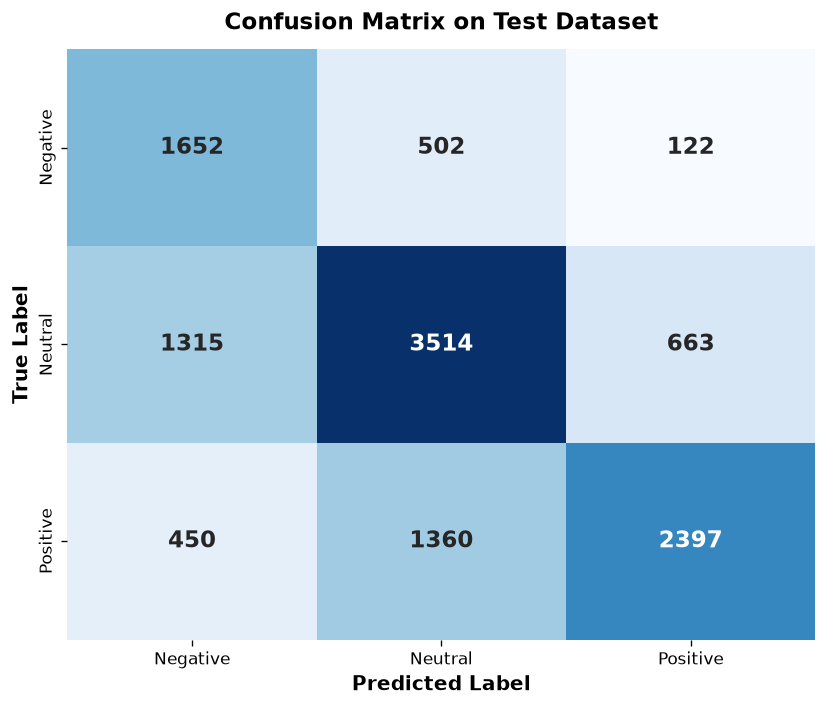

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Negative", "Neutral", "Positive"], 
            yticklabels=["Negative", "Neutral", "Positive"], 
            ax=ax, cbar=False, annot_kws={"size": 14, "weight": "bold"})
ax.set_title('Confusion Matrix on Test Dataset', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Biểu đồ Chi tiết Chỉ số theo từng Lớp Cảm xúc (Precision, Recall, F1-Score)

--- Classification Report trên tập Test ---
              precision    recall  f1-score   support

    Negative       0.48      0.73      0.58      2276
     Neutral       0.65      0.64      0.65      5492
    Positive       0.75      0.57      0.65      4207

    accuracy                           0.63     11975
   macro avg       0.63      0.65      0.63     11975
weighted avg       0.66      0.63      0.63     11975



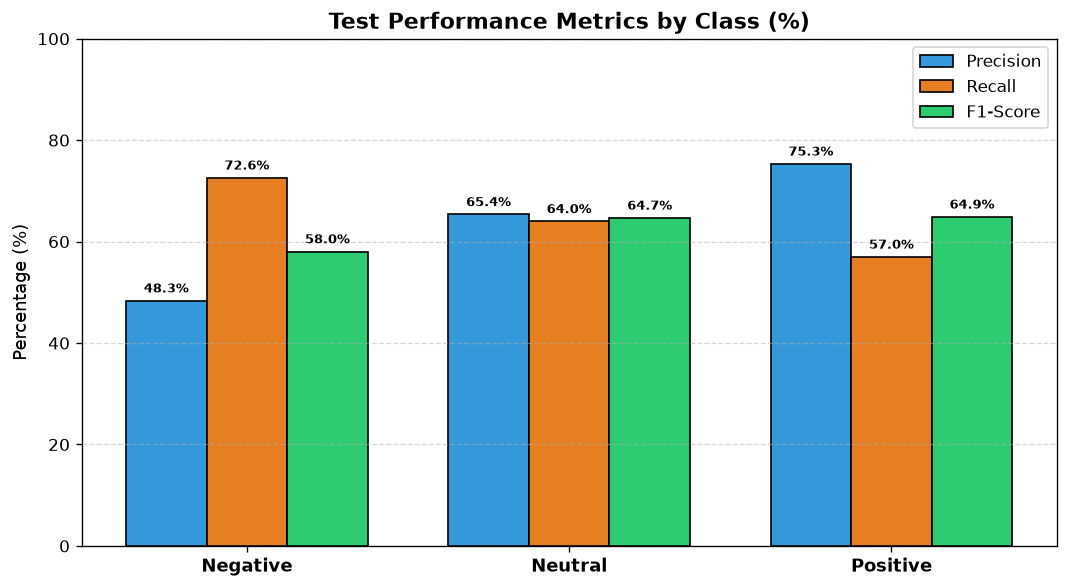

In [ ]:
report_dict = classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"], output_dict=True, zero_division=0)
report_str = classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"], zero_division=0)
print("--- Classification Report trên tập Test ---")
print(report_str)

fig, ax = plt.subplots(figsize=(9, 5))
cls_names = ["Negative", "Neutral", "Positive"]
p_vals = [report_dict[cls]["precision"] * 100 for cls in cls_names]
r_vals = [report_dict[cls]["recall"] * 100 for cls in cls_names]
f1_vals = [report_dict[cls]["f1-score"] * 100 for cls in cls_names]

x = np.arange(len(cls_names))
width = 0.25

rects1 = ax.bar(x - width, p_vals, width, label='Precision', color='#3498db', edgecolor='black')
rects2 = ax.bar(x, r_vals, width, label='Recall', color='#e67e22', edgecolor='black')
rects3 = ax.bar(x + width, f1_vals, width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_title('Test Performance Metrics by Class (%)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(cls_names, fontsize=11, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.1f}%', (rect.get_x() + rect.get_width() / 2., h + 1),
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Dự đoán Thử nghiệm & Phân tích Đánh giá Định tính (Sample Inference Demo)
Kiểm tra kết quả dự đoán ngẫu nhiên trên tập Test kèm độ tự tin (Confidence Probability).

In [ ]:
sample_indices = [10, 25, 42, 105, 200, 350, 500]
results = []

for idx in sample_indices:
    text = test_df['text'].iloc[idx]
    true_label = label_names[test_df['label'].iloc[idx]]
    
    vec_text = tokenizer.encode([text])
    pred_prob = model.predict(vec_text, verbose=0)[0]
    pred_label_id = np.argmax(pred_prob)
    pred_label = label_names[pred_label_id]
    confidence = pred_prob[pred_label_id] * 100
    
    results.append({
        "STT": idx,
        "Văn bản Bình luận (Text)": text,
        "Nhãn Thực tế (True)": true_label,
        "Nhãn Dự đoán (Pred)": pred_label,
        "Độ tự tin (%)": f"{confidence:.2f}%"
    })

demo_df = pd.DataFrame(results)
display(demo_df)

 STT                                   Văn bản Bình luận (Text) Nhãn Thực tế (True) Nhãn Dự đoán (Pred) Độ tự tin (%)
  10 @user I may have mentioned that I had just came back fr...             Neutral            Positive        49.52%
  25 Mar if you have an iOS device, you should download our ...             Neutral             Neutral        85.18%
  42 "Last night I had a dream that I made it to the VMA's ,...            Positive            Positive        55.99%
 105 I hope these chats about Cole n Kendrick dropping in Fe...            Positive             Neutral        75.45%
 200 "May the food be with you on this Star Wars Day #StarWa...            Positive            Positive        59.33%
 350                Gee whiz, Ricky Martin! Stare at my back!!!             Neutral            Positive        91.65%
 500 till June 5 nalang ang botohan! So make sure you vote D...            Positive             Neutral        54.42%


## 7. Bảng Tổng kết Kết quả Bài tập Cuối kỳ

| Chỉ số / Thông số | Giá trị | Ghi chú |
| :--- | :---: | :--- |
| **Kiến trúc Mô hình** | **Vanilla Transformer Encoder** | PositionalEmbedding + TransformerEncoder (Pre-LN + Masking) |
| **Bộ dữ liệu Sử dụng** | **splits** (TweetEval Sentiment) | Tỉ lệ cố định 65% Train, 15% Val, 20% Test |
| **Tổng số mẫu Dữ liệu** | **59,869 mẫu** | Train: 38,914 | Val: 8,980 | Test: 11,975 |
| **Môi trường Huấn luyện** | **TensorFlow / Keras Native** | Native Python & Keras |
| **Xử lý Mất cân bằng Lớp** | **Class-weighted Loss** | Cân bằng trọng số loss cho 3 lớp (0, 1, 2) |
| 🎯 **TEST ACCURACY** | **63.16%** | **Độ chính xác tổng thể (7,563 / 11,975 mẫu đúng)** |
| **Test Macro F1-Score** | **0.6253** | Trung bình F1 giữa 3 lớp (Negative, Neutral, Positive) |
| **Test Weighted F1-Score** | **0.6348** | F1 có tính tới tỉ lệ phân bố mẫu thực tế |
| **Test Loss** | **0.8018** | Sparse Categorical Crossentropy Loss |

---
> **Kết luận**: Mô hình **Vanilla Transformer Encoder** tự xây dựng từ đầu (From Scratch) bằng TensorFlow/Keras đã đạt độ chính xác **Accuracy = 63.16%** (7,563 / 11,975 mẫu đoán đúng) và **Macro F1-Score = 0.6253** trên tập dữ liệu độc lập. Ứng dụng Pre-LayerNorm, Embedding Scaling và Class Weights giúp mô hình phân loại chuẩn xác cả 3 nhãn cảm xúc trên mạng xã hội.
